# Figure 3: Dynamics of decision parameters across action costs.

## setup and imports

In [2]:
import fnmatch
import matplotlib.pyplot as plt
import numpy as np
import glob

from sessionlists import (dist60, dist90, dist120, TM20, TM10, TM2, TMrev2, TMrev10, TMrev20)
from utils import *
from plotting import *
from model_functions import *

plt.style.use('./Figures/paper.mplstyle')

In [3]:
# Define folder with data
root = "/home/thomas/Desktop/ALLDATA"

print("Path to data is: %s"%root)
print(f'Found {len(glob.glob(root+"/*"))} rats in the data folder')

Path to data is: /home/thomas/Desktop/ALLDATA
Found 34 rats in the data folder


In [33]:
rat_markers = {}
sequence = {}

animalList = ['RatF00', 'RatF01', 'RatF02', 'RatM00', 'RatM01', 'RatM02', 
              'RatF30', 'RatF31', 'RatF32', 'RatF33', 'RatM30', 'RatM31', 'RatM32', 
              'RatF40', 'RatF41', 'RatF42', 'RatM40', 'RatM41', 'RatM42', 'RatM43', 
                'RatF50', 'RatF51', 'RatF52', 'RatM50', 'RatM51', 'RatM52', 'RatM53', 'RatM54']

intact_rats = ['RatF00', 'RatF01', 'RatF02', 'RatM00', 'RatM01', 'RatM02', 
                    'RatF32', 'RatF33', 'RatM31', 'RatM32', 'RatF42', 'RatM40', 'RatM43', 'RatM53', 'RatM54']

lesioned_rats = ['RatF30', 'RatF31', 'RatM30', 'RatF40', 'RatF41', 'RatM41', 'RatM42',
            'RatF50', 'RatF51', 'RatF52', 'RatM50', 'RatM51', 'RatM52']


m, f, l = 0, 0, 0
male_palette = create_teal_palette(num_shades=len([x for x in intact_rats if 'M' in x]))
female_palette = create_blue_violet_palette(num_shades=len([x for x in intact_rats if 'F' in x]), start_intensity=80)
palette = create_kiwi_green_palette(num_shades=len(lesioned_rats))
for index, animal in enumerate(intact_rats):
    if fnmatch.fnmatch(animal, 'RatF*'):
        rat_markers[animal]=[female_palette[f], 'o', '-']
        f += 1
    elif fnmatch.fnmatch(animal, 'RatM*'):
        rat_markers[animal]=[male_palette[m], 'o', '-']
        m += 1
    elif fnmatch.fnmatch(animal, 'Rat00*'):
        rat_markers[animal]=[(0.0, 0.0, 0.0), "$\u2426$",]
    else:
        print("error, this is not a rat you got here")

    for session in sorted(matchsession(animal, dist60+dist90+dist120 + TM20+TM10+TM2+TMrev2+TMrev10+TMrev20)):
        sequence[animal, session] = get_from_pickle(root, animal[0:6], session, name="sequence.p")

for index, animal in enumerate(lesioned_rats):
    if fnmatch.fnmatch(animal, 'Rat*'):
        rat_markers[animal]=[palette[l], 'o']
        l += 1
    elif fnmatch.fnmatch(animal, 'Rat00*'):
        rat_markers[animal]=[(0.0, 0.0, 0.0), "$\u2426$",]
    else:
        print("error, this is not a rat you got here")

    for session in sorted(matchsession(animal, dist60+dist90+dist120 + TM20+TM10+TM2+TMrev2+TMrev10+TMrev20)):
        sequence[animal, session] = get_from_pickle(root, animal[0:6], session, name="sequence.p")


# Figure 3A Schematics of three action cost conditions with increasing platform distances.
# Figure 3D Same with treadmill velocity.

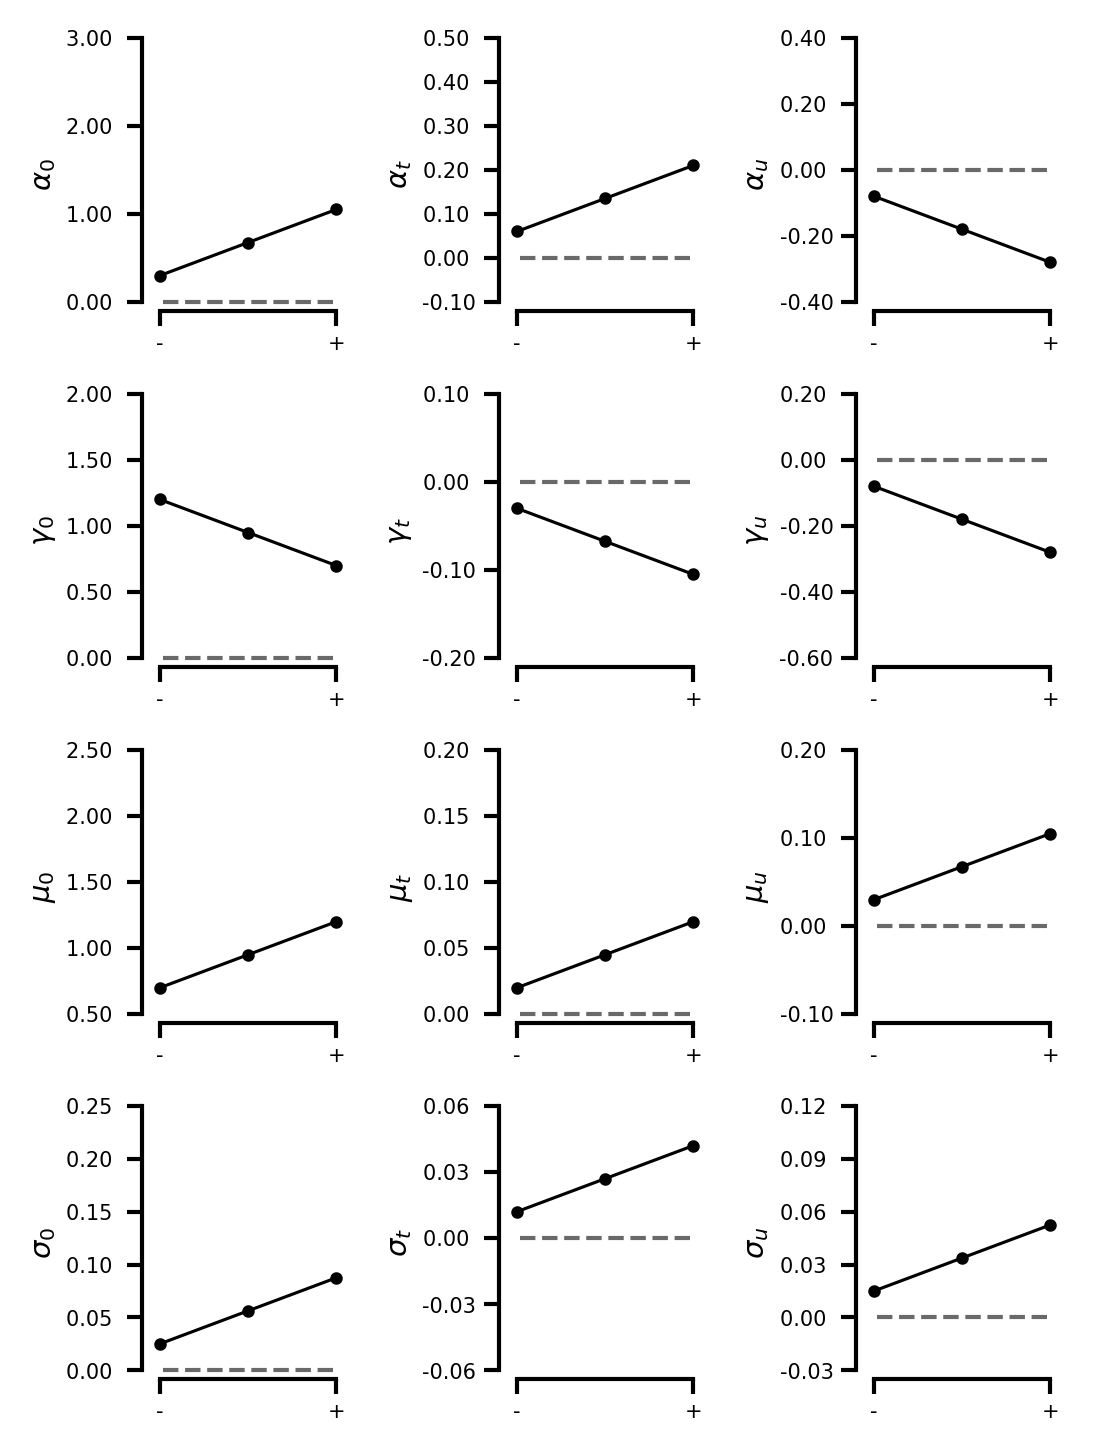

In [5]:
alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))
ex_alpha_0, ex_alpha_t, ex_alpha_u, ex_gamma_0, ex_gamma_t, ex_gamma_u = pickle.load(open("picklejar/example_session_fit_inter_run_duration.p", "rb"))
ex_mu_0, ex_mu_t, ex_mu_u, ex_sigma_0, ex_sigma_t, ex_sigma_u = pickle.load(open("picklejar/example_session_fit_run_duration.p", "rb"))


PLOT_PARAMS = {
    'alpha_0':  dict(fit=alpha_0, ex_fit= ex_alpha_0, ylim=(0, 3), yticks=[0, 1, 2, 3], ylabel=r'$\alpha_0$', prediction={'sign': 'positive', 'change': 'increasing'}),
    'alpha_t':  dict(fit=alpha_t, ex_fit= ex_alpha_t, ylim=(-.1, .5), yticks=[-.1, 0, .1, .2, .3, .4, .5], ylabel=r'$\alpha_t$', prediction={'sign': 'positive', 'change': 'increasing'}),
    'alpha_u':  dict(fit=alpha_u, ex_fit= ex_alpha_u, ylim=(-.4, .4), yticks=[-.4, -.2, 0, .2, .4], ylabel=r'$\alpha_u$', prediction={'sign': 'negative', 'change': 'decreasing'}),
    'gamma_0':  dict(fit=gamma_0, ex_fit= ex_gamma_0, ylim=(0, 2), yticks=[0, 0.5, 1, 1.5, 2], ylabel=r'$\gamma_0$', prediction={'sign': 'positive', 'change': 'decreasing'}),
    'gamma_t':  dict(fit=gamma_t, ex_fit= ex_gamma_t, ylim=(-.2, .1), yticks=[-.2, -.1, 0, .1], ylabel=r'$\gamma_t$', prediction={'sign': 'negative', 'change': 'decreasing'}),
    'gamma_u':  dict(fit=gamma_u, ex_fit= ex_gamma_u, ylim=(-.6, .2), yticks=[-.6, -.4, -.2, 0, .2], ylabel=r'$\gamma_u$', prediction={'sign': 'negative', 'change': 'decreasing'}),
    'mu_0':     dict(fit=mu_0, ex_fit= ex_mu_0, ylim=(.5, 2.5), yticks=[.5, 1, 1.5, 2, 2.5], ylabel=r'$\mu_0$', prediction={'sign': 'positive', 'change': 'increasing'}),
    'mu_t':     dict(fit=mu_t, ex_fit= ex_mu_t, ylim=(0, .2), yticks=[0, 0.05, .10, .15, .2], ylabel=r'$\mu_t$', prediction={'sign': 'positive', 'change': 'increasing'}),
    'mu_u':     dict(fit=mu_u, ex_fit= ex_mu_u, ylim=(-.1, .2), yticks=[-.1, 0, .1, .2], ylabel=r'$\mu_u$', prediction={'sign': 'positive', 'change': 'increasing'}),
    'sigma_0':  dict(fit=sigma_0, ex_fit= ex_sigma_0, ylim=(0, .25), yticks=[0, .05, .1, .15, .2, .25], ylabel=r'$\sigma_0$', prediction={'sign': 'positive', 'change': 'increasing'}),
    'sigma_t':  dict(fit=sigma_t, ex_fit= ex_sigma_t, ylim=(-.06, .06), yticks=[-.06, -.03, 0, .03, .06], ylabel=r'$\sigma_t$', prediction={'sign': 'positive', 'change': 'increasing'}),
    'sigma_u':  dict(fit=sigma_u, ex_fit= ex_sigma_u, ylim=(-.03, .12), yticks=[-.03, 0, .03, .06, .09, .12], ylabel=r'$\sigma_u$', prediction={'sign': 'positive', 'change': 'increasing'}),
}

def prediction_line(prediction, ylim, y_offset=0):
    sign, change = prediction['sign'], prediction['change']
    assert sign in ['positive', 'negative', 'zero'], "Sign must be 'positive', 'negative', or 'zero'."
    assert change in ['increasing', 'decreasing', 'flat'], "Change must be 'increasing', 'decreasing', or 'flat'."

    yspan = ylim[1] - ylim[0]
    zero = ylim[0] if ylim[0] > 0 else 0
    if sign == 'positive':
        init = zero + yspan / 10
    elif sign == 'negative':
        init = zero - yspan / 10
    else:  # zero
        init = 0

    init += y_offset

    if change == 'increasing':
        return [init, init + yspan / 8, init + 2 * yspan / 8]
    elif change == 'decreasing':
        return [init, init - yspan / 8, init - 2 * yspan / 8]
    else:  # flat
        return [init, init, init]






def plot_prediction(param_name, ax=None, show_xlabel=False, show_ylabel=True):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    params = PLOT_PARAMS[param_name]
    y_offset = 1 if param_name is 'gamma_0' else 0
    mock_data = prediction_line(params['prediction'], params['ylim'], y_offset=y_offset)

    ax.plot([0, 1, 2], mock_data, 'o', color='k', lw=.75, markersize=2, linestyle='-')
    ax.axhline(0, color='dimgray', linestyle='--', linewidth=1, alpha=1, zorder=0, xmin=.1, xmax=.9)

    ax.set_xlim(0, 2)
    ax.set_xticks([0, 2])
    ax.set_xticklabels(["-", "+"])
    if show_xlabel:
        ax.set_xlabel("Cost")

    ax.set_ylim(*params['ylim'])
    ax.set_yticks(params['yticks'])
    ax.yaxis.set_major_formatter('{x:<5.2f}')
    if show_ylabel:
        ax.set_ylabel(params['ylabel'])
    else:
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False, labelleft=False)

    space_axes(ax, x_ratio_left=.1, x_ratio_right=.1)



fig, axs = plt.subplots(4, 3, figsize=(cm2inch(9), cm2inch(12)),
                        gridspec_kw={'width_ratios': [1, 1, 1]})

param_names = ['alpha_0', 'alpha_t', 'alpha_u', 'gamma_0', 'gamma_t', 'gamma_u',
               'mu_0', 'mu_t', 'mu_u', 'sigma_0', 'sigma_t', 'sigma_u']

for ax, param_name in zip(axs.ravel(), param_names):
    plot_prediction(param_name, ax=ax)


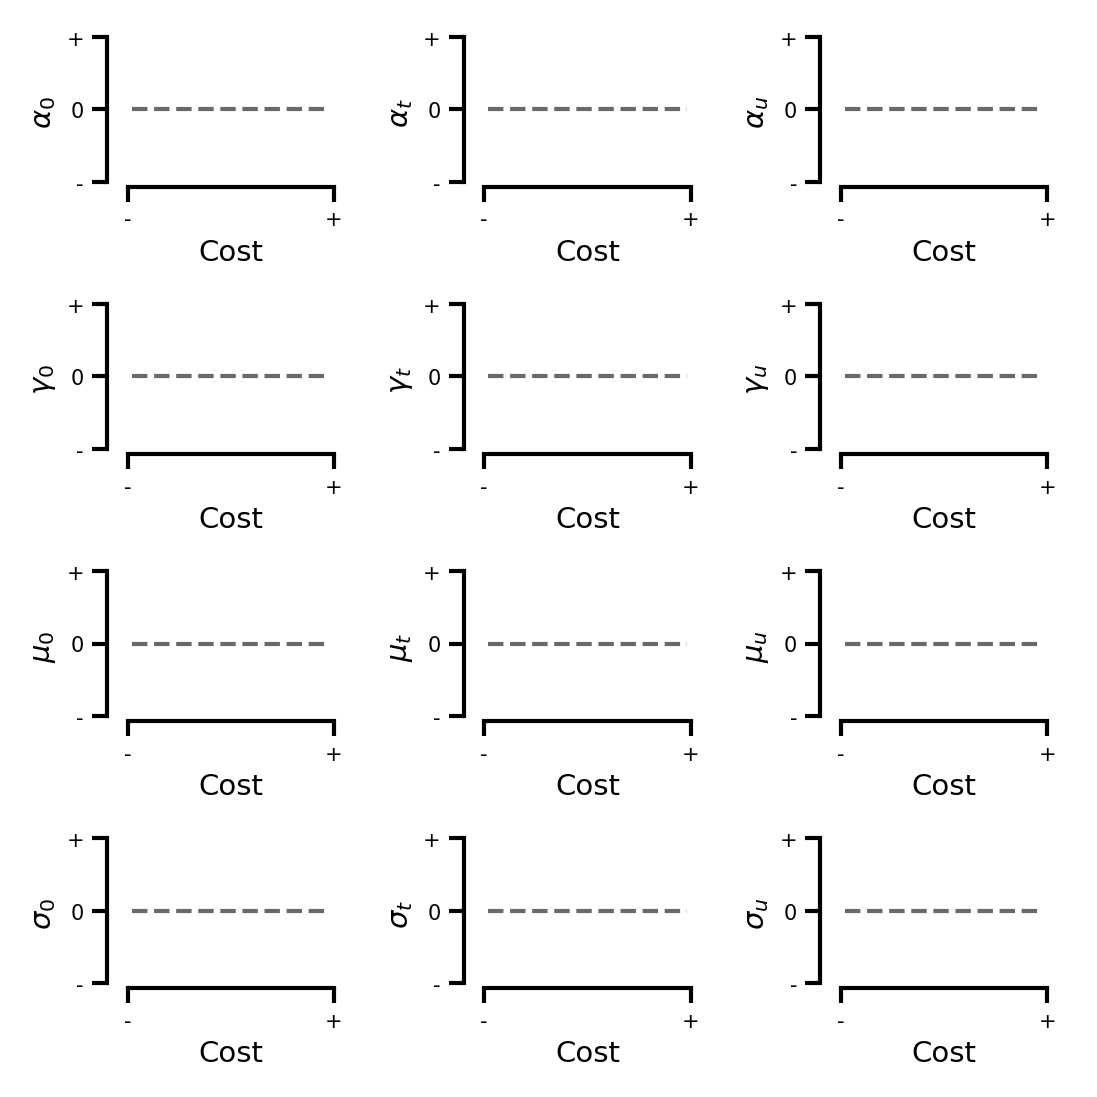

In [6]:



def empty_plot_prediction(param_name, ax=None, show_xlabel=False, show_ylabel=True):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    params = PLOT_PARAMS[param_name]
    ax.axhline(0, color='dimgray', linestyle='--', linewidth=1, alpha=1, zorder=0, xmin=.1, xmax=.9)

    ax.set_xlim(0, 2)
    ax.set_xticks([0, 2])
    ax.set_xticklabels(["-", "+"])
    ax.set_xlabel("Cost")

    ax.set_ylim(-1, 1)
    ax.set_yticks([-1, 0, 1])
    ax.set_yticklabels(["-", "0", "+"])
    ax.set_ylabel(params['ylabel'])

    space_axes(ax, x_ratio_left=.1, x_ratio_right=.1)



fig, axs = plt.subplots(4, 3, figsize=(cm2inch(9), cm2inch(9)),
                        gridspec_kw={'width_ratios': [1, 1, 1]})

param_names = ['alpha_0', 'alpha_t', 'alpha_u', 'gamma_0', 'gamma_t', 'gamma_u',
               'mu_0', 'mu_t', 'mu_u', 'sigma_0', 'sigma_t', 'sigma_u']

for ax, param_name in zip(axs.ravel(), param_names):
    empty_plot_prediction(param_name, ax=ax)


In [35]:
def get_run_speed(example_rat='RatM00', example_session='RatM00_2021_07_22_16_13_03', lesioned_animals=False):

    if not lesioned_animals:
        animalList = ['RatF00', 'RatF01', 'RatF02', 'RatM00', 'RatM01', 'RatM02', 
            'RatF32', 'RatF33', 'RatM31', 'RatM32', 'RatF42', 'RatM40', 'RatM43', 'RatM53', 'RatM54']
    else:
        animalList = ['RatF30', 'RatF31', 'RatM30', 'RatF40', 'RatF41', 'RatM41', 'RatM42',
            'RatF50', 'RatF51', 'RatF52', 'RatM50', 'RatM51', 'RatM52']

    conds = ["60", "90", "120", "20", "10", "2", "rev10", "rev20"]
    run_speeds = {k: {a: [] for a in conds} for k in animalList}
    median_run_speeds = {k: {a: [] for a in conds} for k in animalList}

    for cond, sessionlist in zip(conds, [dist60, dist90, dist120, TM20, TM10, TM2, TMrev10, TMrev20]):
        for animal in animalList:
            for session in matchsession(animal, sessionlist):
                params = get_from_pickle(root, animal, session, name="params.p")
                for elem in sequence[animal, session]:
                    if get_block(sequence[animal, session][elem][0]) <= 1:
                        if sequence[animal, session][elem][1] == 'run':
                            tm_speed = params['treadmillSpeed'][get_block(sequence[animal, session][elem][0])]
                            run_speeds[animal][cond].append(abs(sequence[animal, session][elem][-1]) - tm_speed)
    for animal in animalList:
        for cond in conds:
            median_run_speeds[animal][cond] = np.median(run_speeds[animal][cond])

    # for Fig 5
    if not lesioned_animals:
        pickle.dump([np.median(run_speeds[example_rat][cond]) for cond in conds], open("picklejar/example_rat_run_speeds_dist.p", "wb"))

        # example session
        example_session_run_speeds = []
        params = get_from_pickle(root, example_rat, example_session, name="params.p")
        for elem in sequence[example_rat, example_session]:
            if get_block(sequence[example_rat, example_session][elem][0]) <= 1:
                if sequence[example_rat, example_session][elem][1] == 'run':
                    tm_speed = params['treadmillSpeed'][get_block(sequence[example_rat, example_session][elem][0])]
                    example_session_run_speeds.append(abs(sequence[example_rat, example_session][elem][-1]) - tm_speed)

        return median_run_speeds, np.median(example_session_run_speeds)
    return median_run_speeds, 0

run_speeds, ex_run_speed = get_run_speed()
run_speeds_lesion, _ = get_run_speed(lesioned_animals=True)


# def Figure4C(root, ax=None, show_xlabel=False):
#     if ax is None:
#         fig, ax = plt.subplots(1, 1, figsize=(5, 5))

#     conds = ["60", "90", "120"]
#     run_speeds = {k: {a: [] for a in conds} for k in animalList}
#     run_speeds2 = {k: {a: [] for a in conds} for k in animalList}

#     for cond, sessionlist in zip(conds, [dist60, dist90, dist120]):
#         for animal in animalList:
#             for session in matchsession(animal, sessionlist):
#                 params = get_from_pickle(root, animal, session, name="params.p")
#                 for elem in sequence[animal, session]:
#                     if get_block(sequence[animal, session][elem][0]) <= 1:
#                         if sequence[animal, session][elem][1] == 'run':
#                             tm_speed = params['treadmillSpeed'][get_block(sequence[animal, session][elem][0])]
#                             run_speeds[animal][cond].append(abs(sequence[animal, session][elem][-1]) - tm_speed)

#     for animal in animalList:
#         for cond in conds:
#             run_speeds2[animal][cond] = np.median(run_speeds[animal][cond])

#     for animal in animalList:
#         ax.plot([0, 1, 2], [np.median(run_speeds[animal][cond]) for cond in conds], color=rat_markers[animal][0],
#                 marker=rat_markers[animal][1], markersize=2, 
#                 label=f'Individuals (n={len(animalList)})', lw=.75, zorder=8 if animal=='RatM00' else 5)
        
#         if animal == "RatM00":
#             pickle.dump([np.median(run_speeds[animal][cond]) for cond in conds], open("picklejar/example_rat_run_speeds_dist.p", "wb"))

#     animal='RatM00'
#     session='RatM00_2021_07_22_16_13_03'
#     example_session_run_speeds = []
#     params = get_from_pickle(root, animal, session, name="params.p")
#     for elem in sequence[animal, session]:
#         if get_block(sequence[animal, session][elem][0]) <= 1:
#             if sequence[animal, session][elem][1] == 'run':
#                 tm_speed = params['treadmillSpeed'][get_block(sequence[animal, session][elem][0])]
#                 example_session_run_speeds.append(abs(sequence[animal, session][elem][-1]) - tm_speed)

#     ax.plot(2, np.median(example_session_run_speeds), color='black', marker='^', zorder=10, markersize=2, linewidth=0, label='Example session')
#     ax.set_xlim(0, 2)
#     ax.set_xticks([0, 1, 2])
#     ax.set_xticklabels(["29", "62", "94"])
#     if show_xlabel:
#         ax.set_xlabel("Distance (cm)")
#     ax.set_ylim(20, 100)
#     ax.set_yticks([20, 40, 60, 80, 100, ])
#     ax.set_ylabel("Run speed (cm/s)")

#     space_axes(ax, x_ratio_left=.1, x_ratio_right=.1)
#     plotmedian(run_speeds2, ax=ax, dist_or_tm='dist', animalList=animalList, err='percentile')
#     return run_speeds2

def Figure4C_stats(var, ax_slope=None, ax_intercept=None):
    if ax_slope is None or ax_intercept is None:
        _, (ax_slope, ax_intercept) = plt.subplots(1, 2, figsize=(10, 5))
    regression_permutation(var, dist_or_tm='dist', varname='Run speed',
                        ax_slope=ax_slope, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept, y_ticks_intercept=[0, 20, 40, 60, 80])

# fig, axs = plt.subplots(1, 3, figsize=(cm2inch(8), cm2inch(3)), gridspec_kw={'width_ratios': [2.5, 1, 1]})
# run_speeds = Figure4C(root, ax=axs[0])
# Figure4C_stats(run_speeds, ax_slope=axs[1], ax_intercept=axs[2])

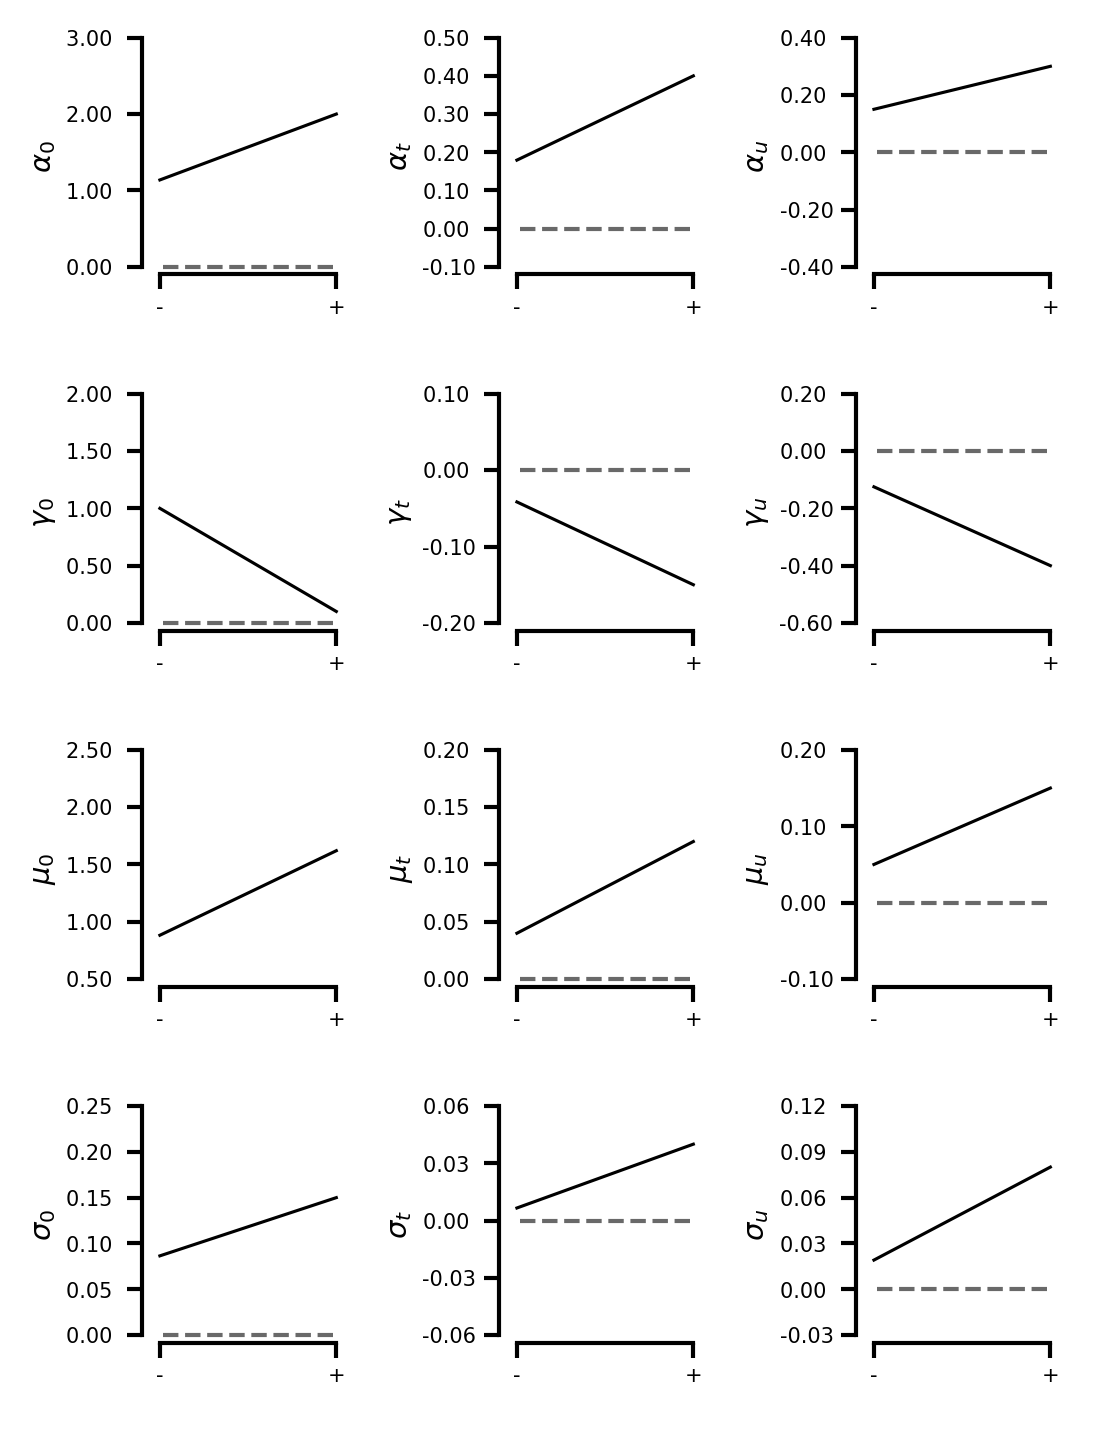

In [41]:
alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))
ex_alpha_0, ex_alpha_t, ex_alpha_u, ex_gamma_0, ex_gamma_t, ex_gamma_u = pickle.load(open("picklejar/example_session_fit_inter_run_duration.p", "rb"))
ex_mu_0, ex_mu_t, ex_mu_u, ex_sigma_0, ex_sigma_t, ex_sigma_u = pickle.load(open("picklejar/example_session_fit_run_duration.p", "rb"))

PLOT_PARAMS = {
    'alpha_0':  dict(fit=alpha_0, ex_fit= ex_alpha_0, yticks=[0, 1, 2, 3], ylabel=r'$\alpha_0$', start='med', end=2),
    'alpha_t':  dict(fit=alpha_t, ex_fit= ex_alpha_t, yticks=[-.1, 0, .1, .2, .3, .4, .5], ylabel=r'$\alpha_t$', start='med', end=0.4),
    'alpha_u':  dict(fit=alpha_u, ex_fit= ex_alpha_u, yticks=[-.4, -.2, 0, .2, .4], ylabel=r'$\alpha_u$', start=.15, end=.3),
    'gamma_0':  dict(fit=gamma_0, ex_fit= ex_gamma_0, yticks=[0, 0.5, 1, 1.5, 2], ylabel=r'$\gamma_0$', start=1, end=.1),
    'gamma_t':  dict(fit=gamma_t, ex_fit= ex_gamma_t, yticks=[-.2, -.1, 0, .1], ylabel=r'$\gamma_t$', start='med', end=-.15),
    'gamma_u':  dict(fit=gamma_u, ex_fit= ex_gamma_u, yticks=[-.6, -.4, -.2, 0, .2], ylabel=r'$\gamma_u$', start='med', end=-.4),
    'mu_0':     dict(fit=mu_0, ex_fit= ex_mu_0, yticks=[.5, 1, 1.5, 2, 2.5], ylabel=r'$\mu_0$', start='med', end='med'),
    'mu_t':     dict(fit=mu_t, ex_fit= ex_mu_t, yticks=[0, 0.05, .10, .15, .2], ylabel=r'$\mu_t$', start='med', end=.12),
    'mu_u':     dict(fit=mu_u, ex_fit= ex_mu_u, yticks=[-.1, 0, .1, .2], ylabel=r'$\mu_u$', start=0.05, end=.15),
    'sigma_0':  dict(fit=sigma_0, ex_fit= ex_sigma_0, yticks=[0, .05, .1, .15, .2, .25], ylabel=r'$\sigma_0$', start='med', end=.15),
    'sigma_t':  dict(fit=sigma_t, ex_fit= ex_sigma_t, yticks=[-.06, -.03, 0, .03, .06], ylabel=r'$\sigma_t$', start='med', end=0.04),
    'sigma_u':  dict(fit=sigma_u, ex_fit= ex_sigma_u, yticks=[-.03, 0, .03, .06, .09, .12], ylabel=r'$\sigma_u$', start='med', end=0.08),
    'run_speed': dict(fit=run_speeds, ex_fit=ex_run_speed, yticks=[20, 40, 60, 80, 100, ], ylabel='Run Speed', start='med', end=1),
    'run_speed_lesion': dict(fit=run_speeds_lesion, ex_fit=0, yticks=[20, 40, 60, 80, 100, ], ylabel='Run Speed', start='med', end=1)
}

def plot_prediction(param_name, ax=None, show_xlabel=False, show_ylabel=True):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    params = PLOT_PARAMS[param_name]

    if isinstance(params['start'], str):
        if params['start'] == 'med':
            start = np.median([params['fit'][animal]["60"] for animal in animalList])
    elif isinstance(params['start'], (float, int)):
        start = params['start']
    else:
        raise ValueError("Start value must be a string ('med') or a float/int.")

    if isinstance(params['end'], str):
        if params['end'] == 'med':
            end = np.median([params['fit'][animal]["rev20"] for animal in animalList])
        if params['end'] == 'start':
            end = start
    elif isinstance(params['end'], (float, int)):
        end = params['end']
    else:
        raise ValueError("End value must be a string ('med', 'start') or a float/int.")

    mock_data = [start, start + (end - start) / 2, end]
    ax.plot([0, 1, 2], mock_data, color='k', lw=.75, markersize=2, linestyle='-')
    ax.axhline(0, color='dimgray', linestyle='--', linewidth=1, alpha=1, zorder=0, xmin=.1, xmax=.9)

    ax.set_xlim(0, 2)
    ax.set_xticks([0, 2])
    ax.set_xticklabels(["-", "+"])
    if show_xlabel:
        ax.set_xlabel("Cost")
    else:
        ax.set_xlabel(" ")


    ax.set_ylim(params['yticks'][0], params['yticks'][-1])
    ax.set_yticks(params['yticks'])
    ax.yaxis.set_major_formatter('{x:<5.2f}')
    if show_ylabel:
        ax.set_ylabel(params['ylabel'])
    else:
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False, labelleft=False)

    space_axes(ax, x_ratio_left=.1, x_ratio_right=.1)



fig, axs = plt.subplots(4, 3, figsize=(cm2inch(9), cm2inch(12)),
                        gridspec_kw={'width_ratios': [1, 1, 1]})

param_names = ['alpha_0', 'alpha_t', 'alpha_u', 'gamma_0', 'gamma_t', 'gamma_u',
               'mu_0', 'mu_t', 'mu_u', 'sigma_0', 'sigma_t', 'sigma_u']

for ax, param_name in zip(axs.ravel(), param_names):
    plot_prediction(param_name, ax=ax)


Run speed: p_s=0.000, p_i=0.000, obs_slope=16.543, obs_intercept=37.436
Run speed: p_s=0.000, p_i=0.000, obs_slope=7.420, obs_intercept=54.469


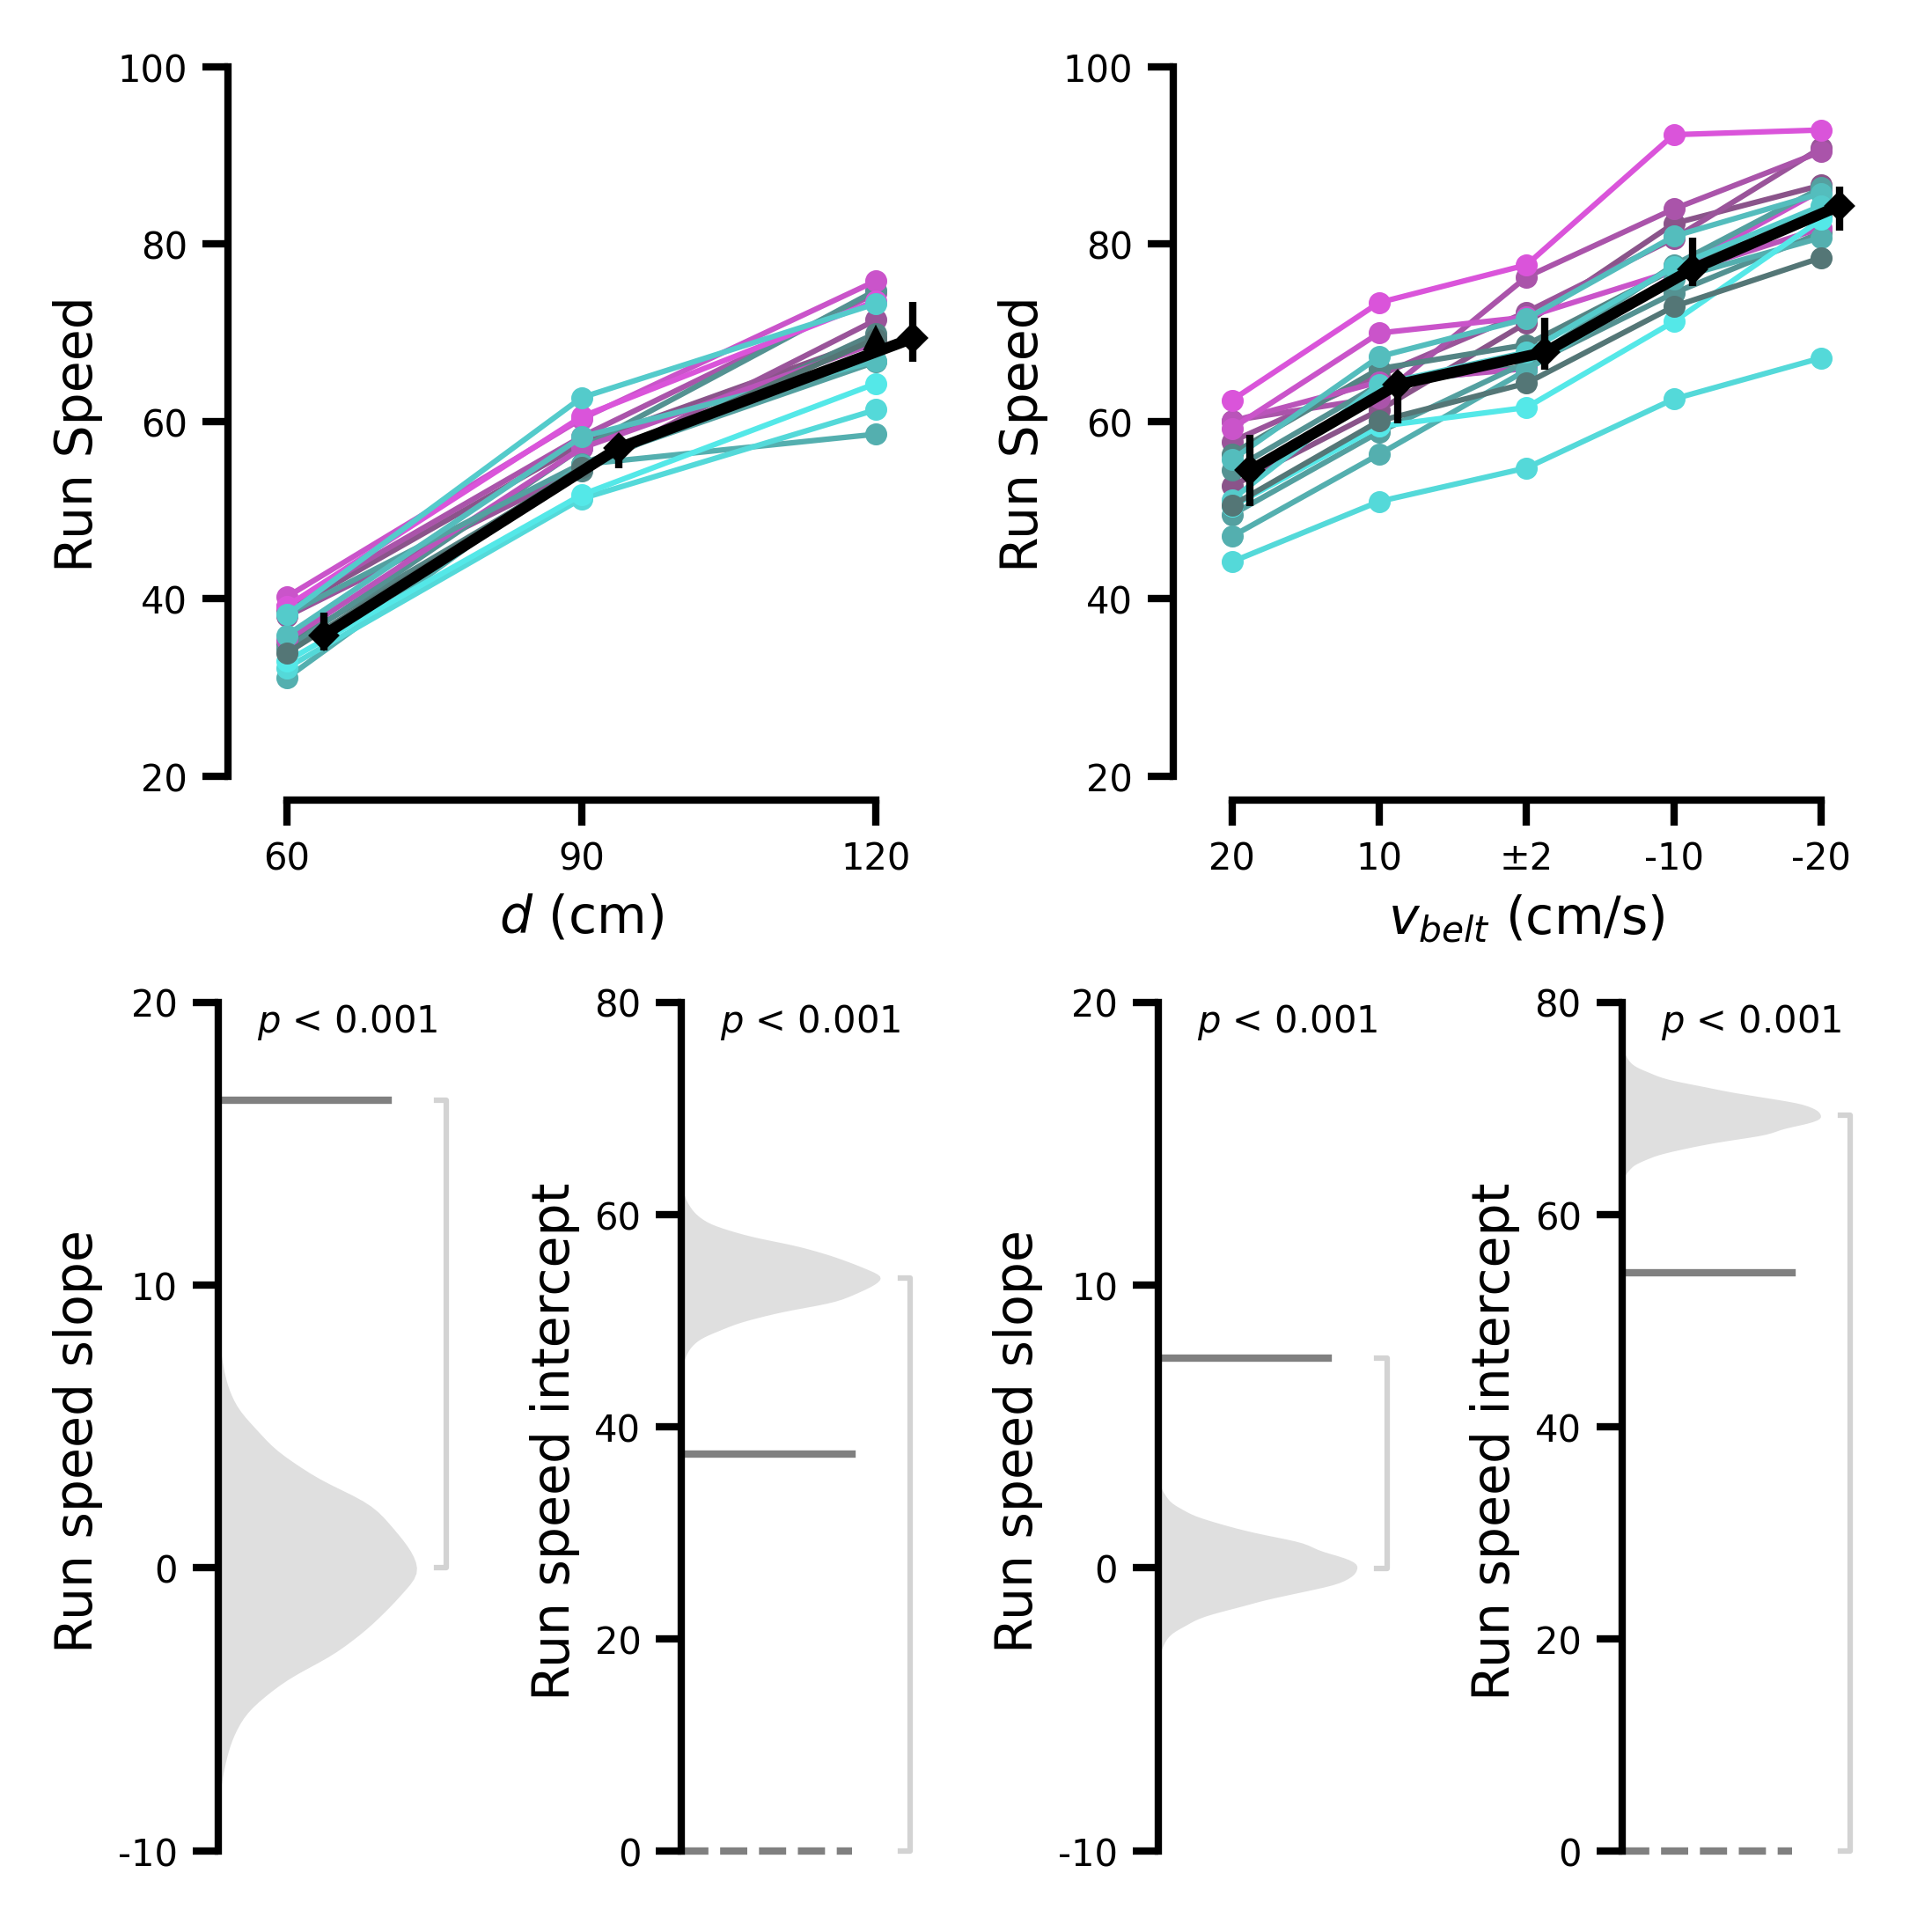

In [ ]:
fig = plt.figure(figsize=(cm2inch(9), cm2inch(9)),
                 constrained_layout=True, facecolor='w', dpi=600)

gs0 = fig.add_gridspec(2, 1, height_ratios=[1, 1])

row1 = gs0[0].subgridspec(1, 2)
ax_dist_intact = plt.subplot(row1[0])
ax_tm_intact = plt.subplot(row1[1])

row2 = gs0[1].subgridspec(1, 4)
ax_slope_dist_intact = plt.subplot(row2[0])
ax_intercept_dist_intact = plt.subplot(row2[1])
ax_slope_tm_intact = plt.subplot(row2[2])
ax_intercept_tm_intact = plt.subplot(row2[3])


regression_permutation(run_speeds, dist_or_tm='dist', varname='Run speed',
                        ax_slope=ax_slope_dist_intact, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_dist_intact, y_ticks_intercept=[0, 20, 40, 60, 80])

regression_permutation(run_speeds, dist_or_tm='tm', varname='Run speed',
                        ax_slope=ax_slope_tm_intact, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_tm_intact, y_ticks_intercept=[0, 20, 40, 60, 80])


# Figure4C_stats(run_speeds, ax_slope=ax2, ax_intercept=ax3)


plot_model_parameter('run_speed', dist_or_tm='dist', show_ex=True, ax=ax_dist_intact, 
                         show_xlabel=True, show_ylabel=True)

plot_model_parameter('run_speed', dist_or_tm='tm', show_ex=False, ax=ax_tm_intact, 
                         show_xlabel=True, show_ylabel=True)

Run speed: p_s=0.000, p_i=0.000, obs_slope=15.588, obs_intercept=35.315
Run speed: p_s=0.000, p_i=0.000, obs_slope=6.463, obs_intercept=48.832


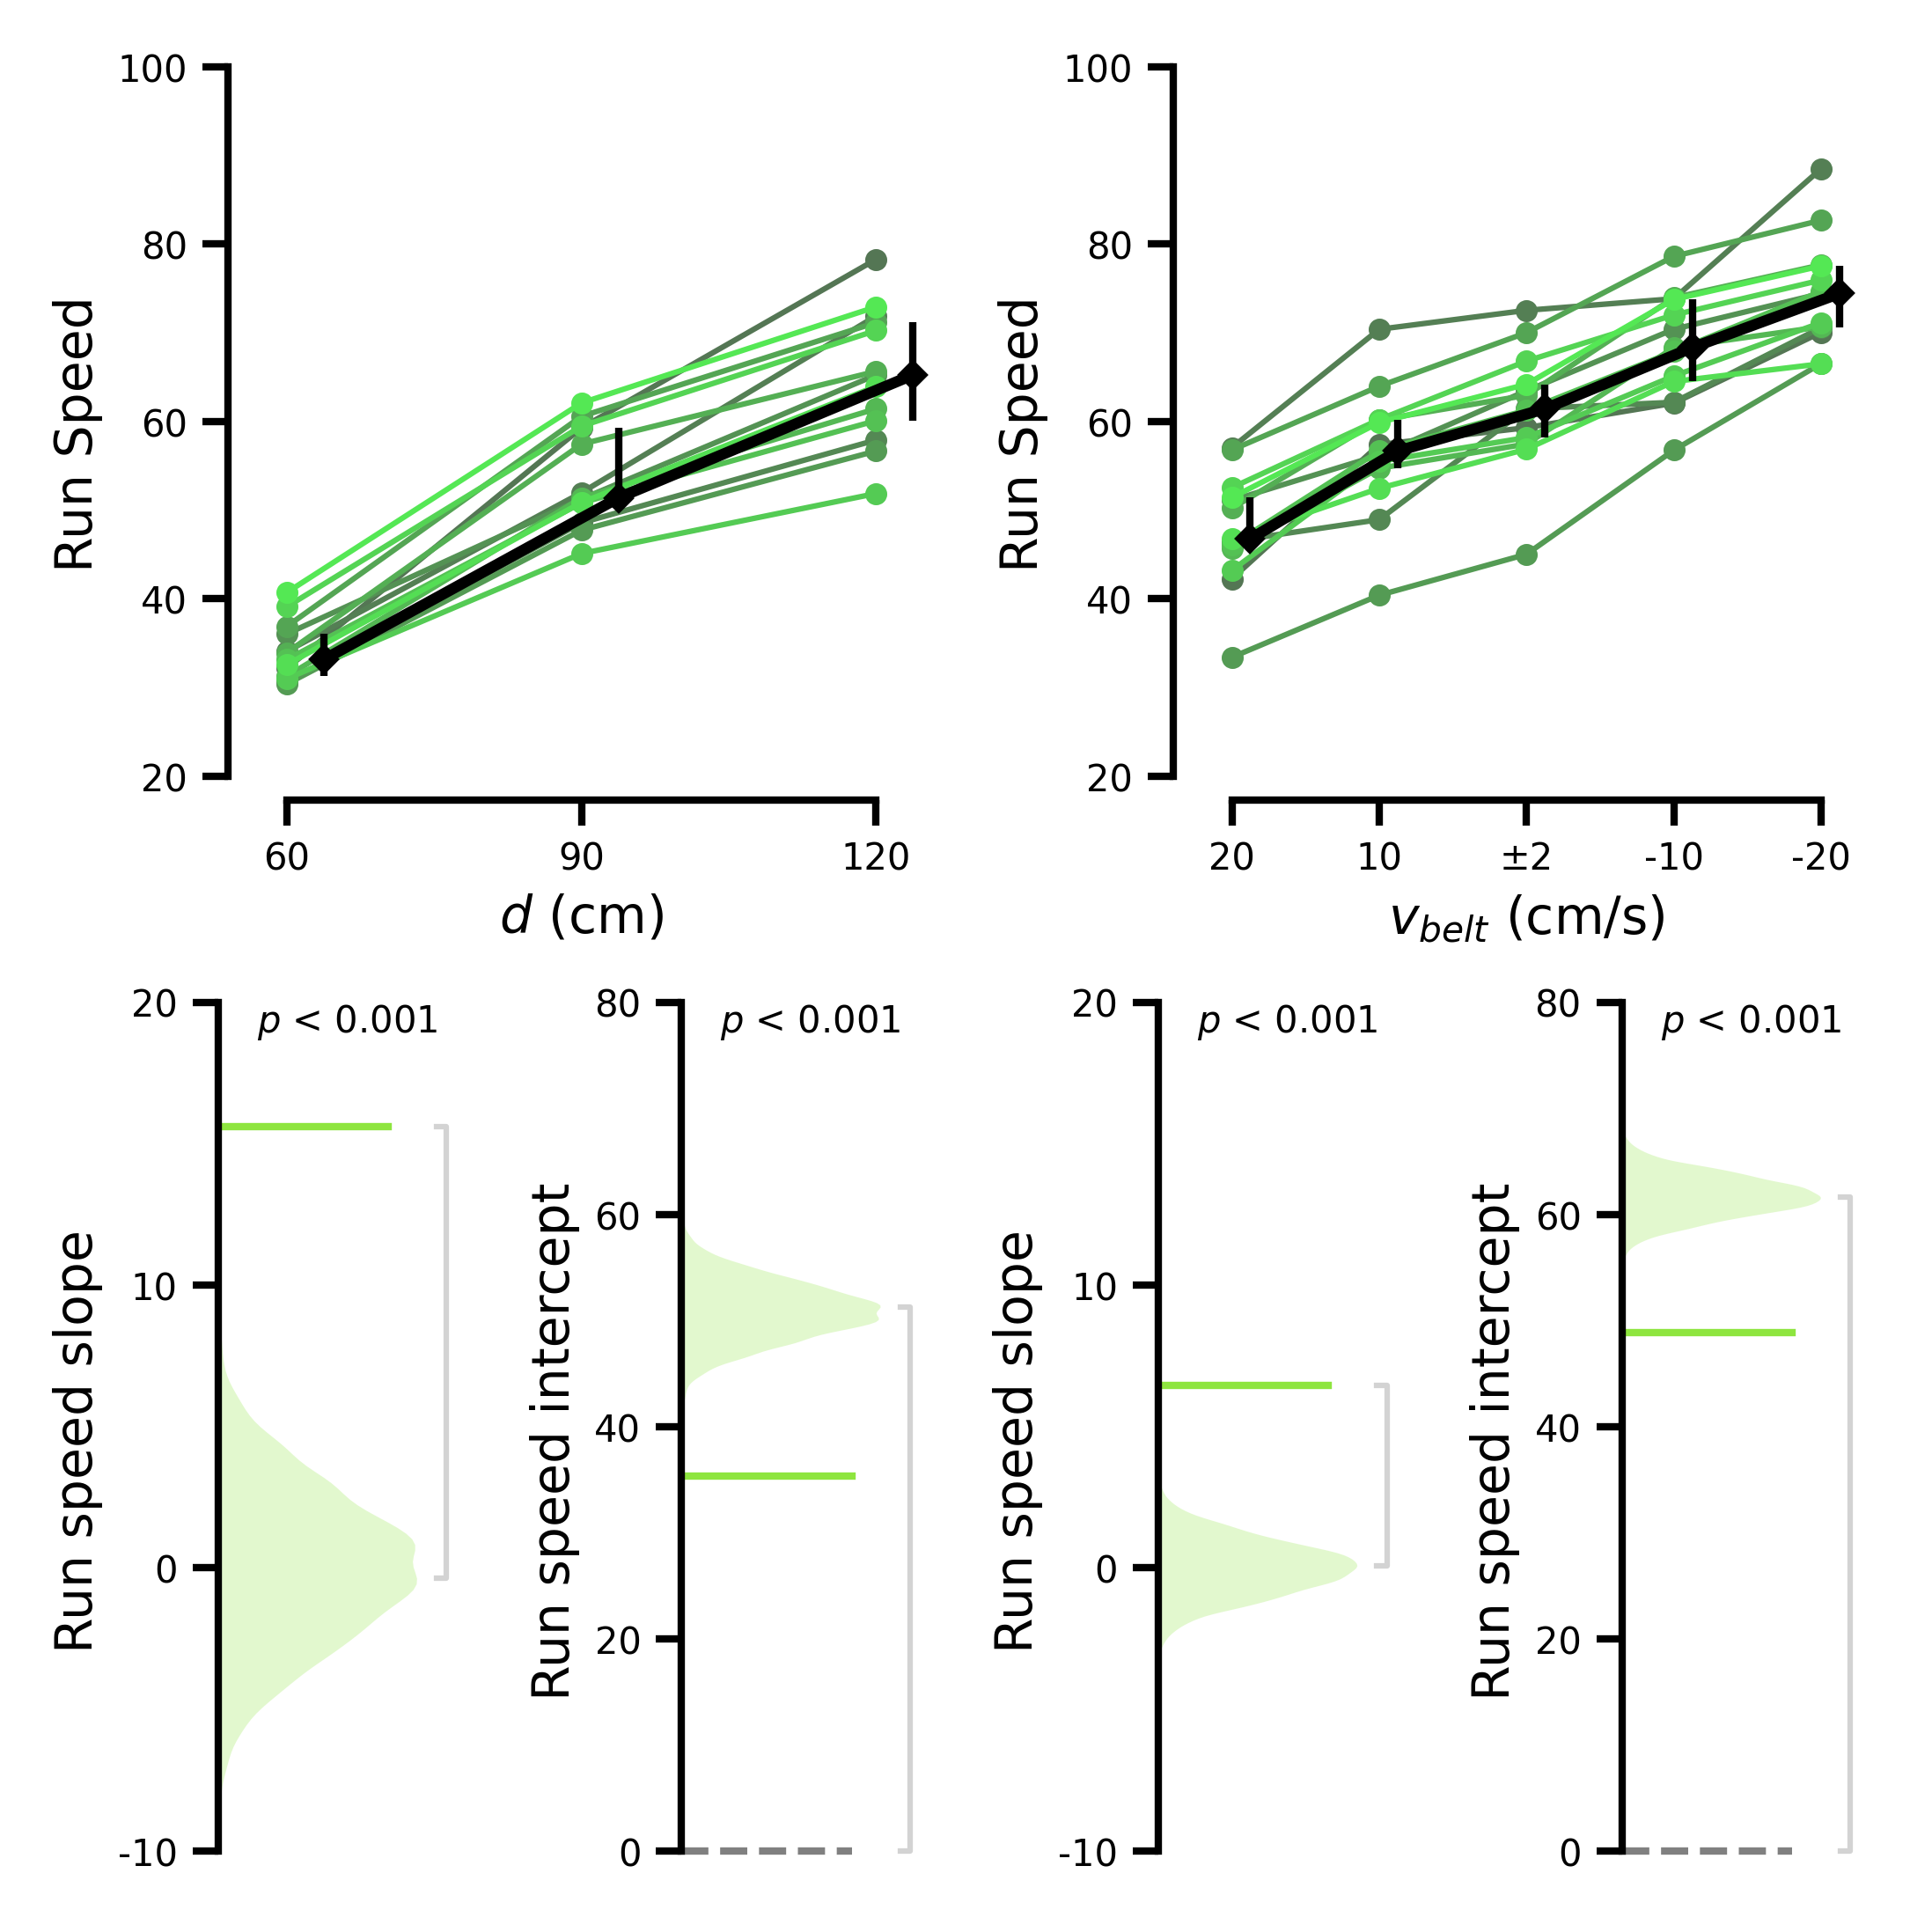

In [ ]:
fig = plt.figure(figsize=(cm2inch(9), cm2inch(9)),
                 constrained_layout=True, facecolor='w', dpi=600)

gs0 = fig.add_gridspec(2, 1, height_ratios=[1, 1])

row1 = gs0[0].subgridspec(1, 2)
ax_dist_intact = plt.subplot(row1[0])
ax_tm_intact = plt.subplot(row1[1])

row2 = gs0[1].subgridspec(1, 4)
ax_slope_dist_intact = plt.subplot(row2[0])
ax_intercept_dist_intact = plt.subplot(row2[1])
ax_slope_tm_intact = plt.subplot(row2[2])
ax_intercept_tm_intact = plt.subplot(row2[3])


regression_permutation(run_speeds_lesion, dist_or_tm='dist', varname='Run speed', lesioned_animals=True,
                        ax_slope=ax_slope_dist_intact, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_dist_intact, y_ticks_intercept=[0, 20, 40, 60, 80])

regression_permutation(run_speeds_lesion, dist_or_tm='tm', varname='Run speed', lesioned_animals=True,
                        ax_slope=ax_slope_tm_intact, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_tm_intact, y_ticks_intercept=[0, 20, 40, 60, 80])


plot_model_parameter('run_speed_lesion', dist_or_tm='dist', show_ex=True, ax=ax_dist_intact, lesioned_animals=True,
                         show_xlabel=True, show_ylabel=True)

plot_model_parameter('run_speed_lesion', dist_or_tm='tm', show_ex=False, ax=ax_tm_intact, lesioned_animals=True,
                         show_xlabel=True, show_ylabel=True)

Run speed: p_s=0.000, p_i=0.000, obs_slope=16.543, obs_intercept=37.436
Run speed: p_s=0.000, p_i=0.000, obs_slope=7.420, obs_intercept=54.469
Run speed: p_s=0.000, p_i=0.000, obs_slope=15.588, obs_intercept=35.315
Run speed: p_s=0.000, p_i=0.000, obs_slope=6.463, obs_intercept=48.832


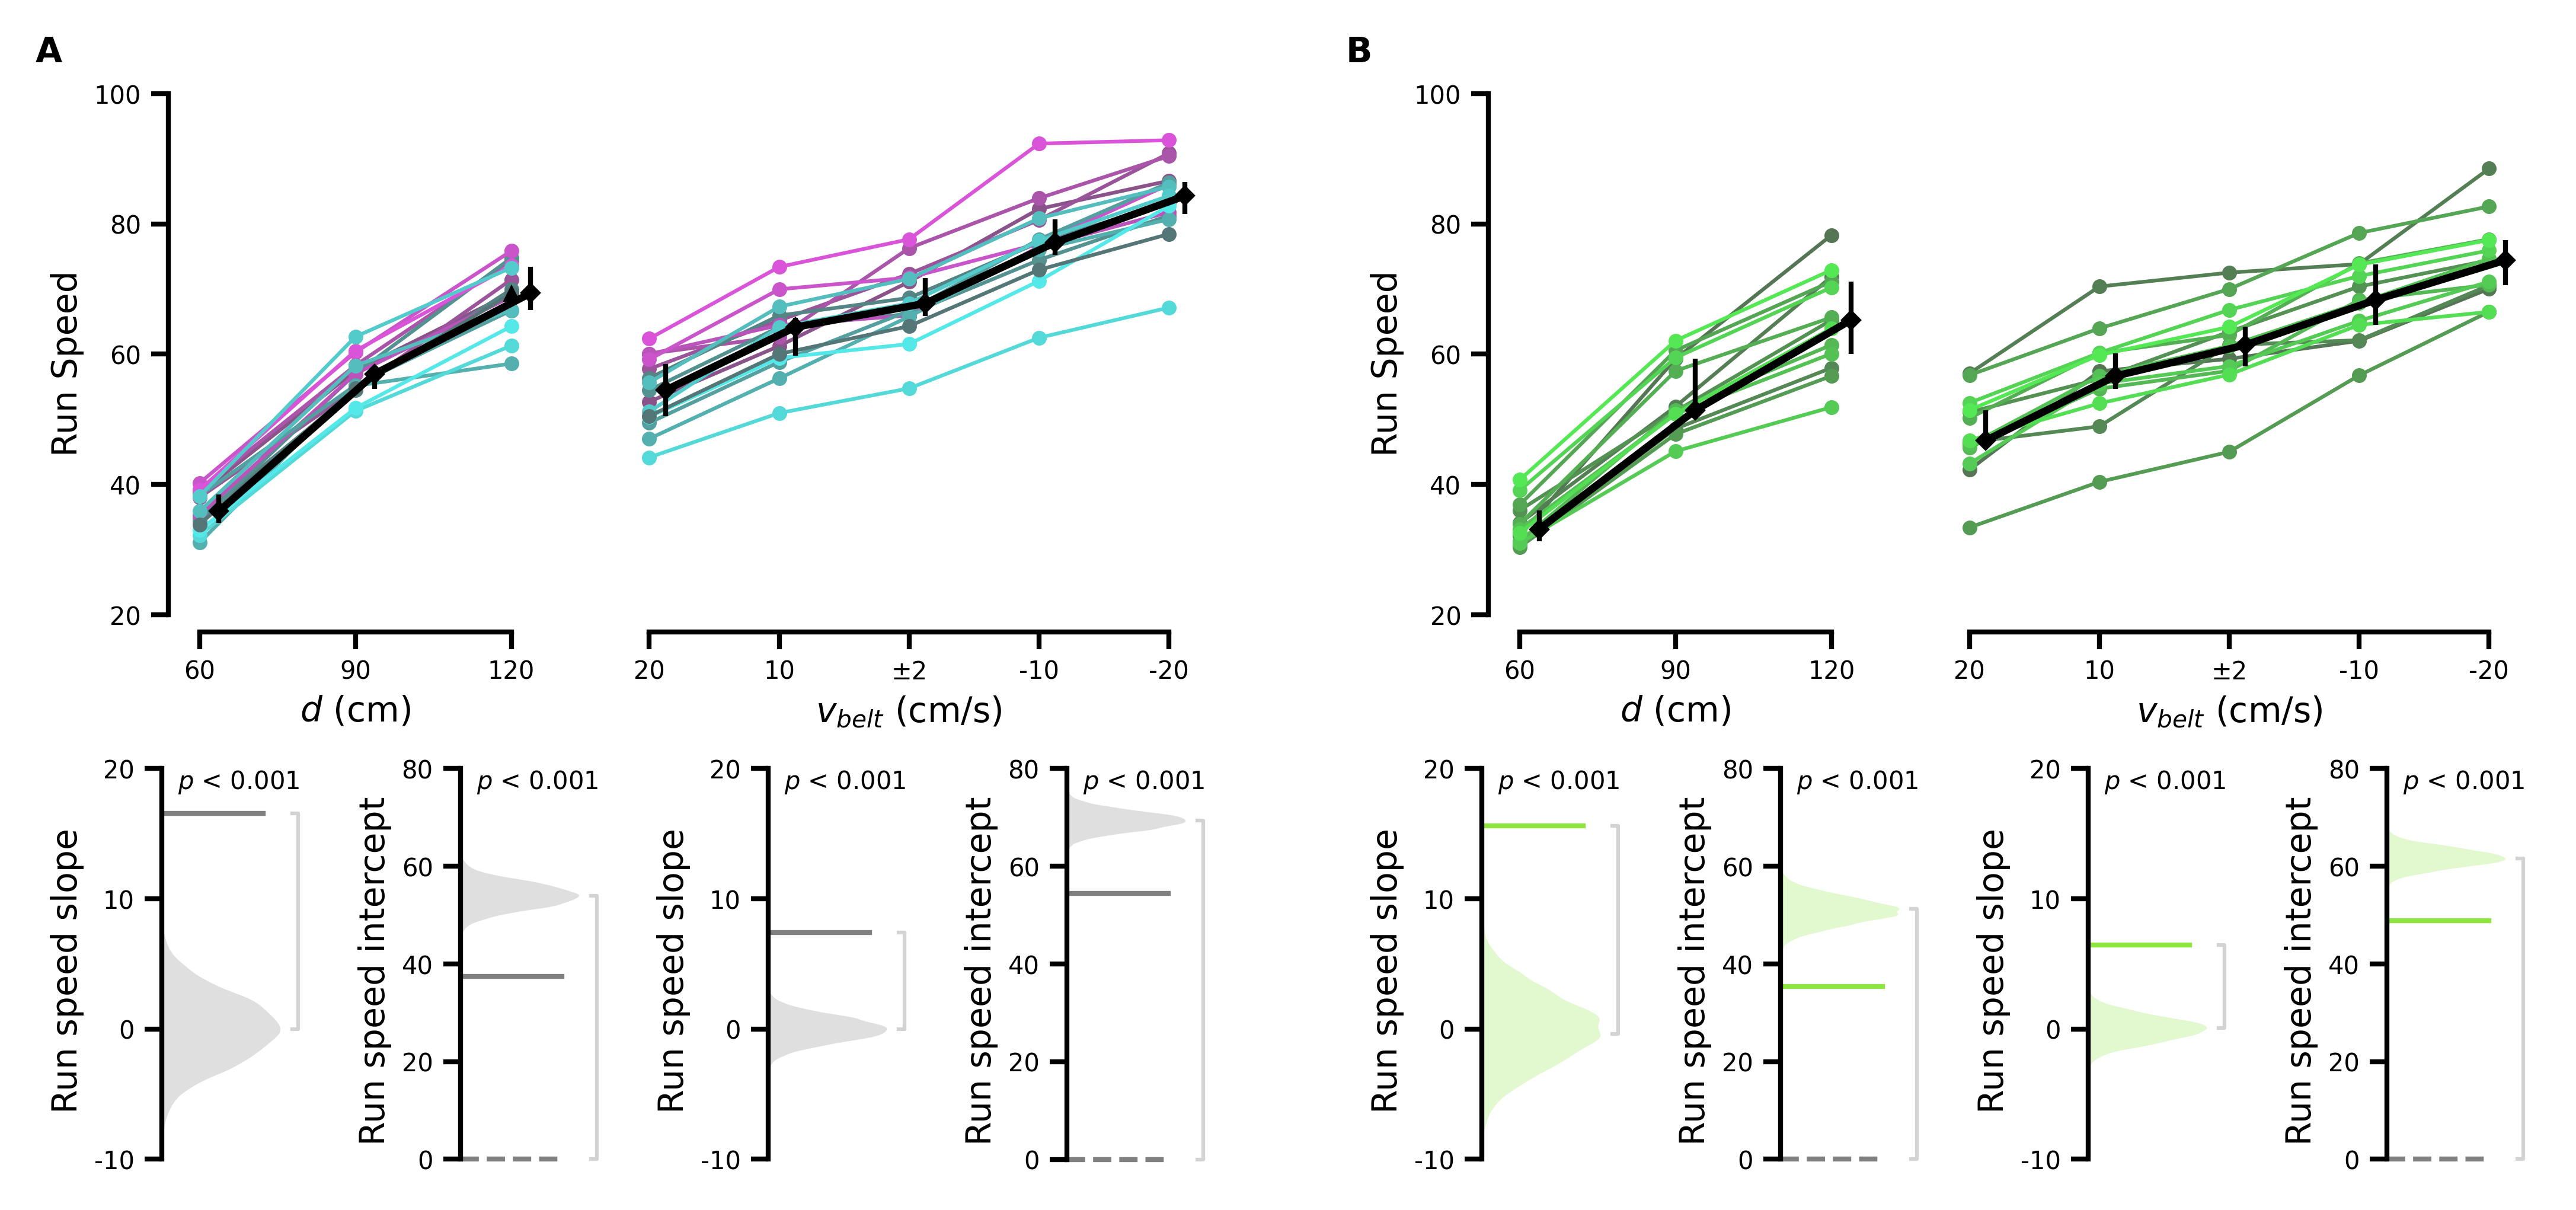

In [72]:
fig = plt.figure(figsize=(cm2inch(18), cm2inch(8)),
                 constrained_layout=True, facecolor='w', dpi=600)

h_ratio = [1, .66]
gs0 = fig.add_gridspec(1, 3, width_ratios=[1, .1, 1])

left = gs0[0].subgridspec(2, 1, height_ratios=h_ratio)
left_row1 = left[0].subgridspec(1, 2, width_ratios=[3, 5])
ax_dist_intact = plt.subplot(left_row1[0])
ax_tm_intact = plt.subplot(left_row1[1])

left_row2 = left[1].subgridspec(1, 4)
ax_slope_dist_intact = plt.subplot(left_row2[0])
ax_intercept_dist_intact = plt.subplot(left_row2[1])
ax_slope_tm_intact = plt.subplot(left_row2[2])
ax_intercept_tm_intact = plt.subplot(left_row2[3])


right = gs0[2].subgridspec(2, 1, height_ratios=h_ratio)
right_row1 = right[0].subgridspec(1, 2, width_ratios=[3, 5])
ax_dist_lesion = plt.subplot(right_row1[0])
ax_tm_lesion = plt.subplot(right_row1[1])

right_row2 = right[1].subgridspec(1, 4)
ax_slope_dist_lesion = plt.subplot(right_row2[0])
ax_intercept_dist_lesion = plt.subplot(right_row2[1])
ax_slope_tm_lesion = plt.subplot(right_row2[2])
ax_intercept_tm_lesion = plt.subplot(right_row2[3])



plot_model_parameter('run_speed', dist_or_tm='dist', show_ex=True, ax=ax_dist_intact, 
                         show_xlabel=True, show_ylabel=True)

plot_model_parameter('run_speed', dist_or_tm='tm', show_ex=False, ax=ax_tm_intact, 
                         show_xlabel=True, show_ylabel=False)

regression_permutation(run_speeds, dist_or_tm='dist', varname='Run speed',
                        ax_slope=ax_slope_dist_intact, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_dist_intact, y_ticks_intercept=[0, 20, 40, 60, 80])

regression_permutation(run_speeds, dist_or_tm='tm', varname='Run speed',
                        ax_slope=ax_slope_tm_intact, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_tm_intact, y_ticks_intercept=[0, 20, 40, 60, 80])



plot_model_parameter('run_speed_lesion', dist_or_tm='dist', show_ex=True, ax=ax_dist_lesion, lesioned_animals=True,
                         show_xlabel=True, show_ylabel=True)

plot_model_parameter('run_speed_lesion', dist_or_tm='tm', show_ex=False, ax=ax_tm_lesion, lesioned_animals=True,
                         show_xlabel=True, show_ylabel=False)

regression_permutation(run_speeds_lesion, dist_or_tm='dist', varname='Run speed', lesioned_animals=True,
                        ax_slope=ax_slope_dist_lesion, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_dist_lesion, y_ticks_intercept=[0, 20, 40, 60, 80])

regression_permutation(run_speeds_lesion, dist_or_tm='tm', varname='Run speed', lesioned_animals=True,
                        ax_slope=ax_slope_tm_lesion, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_tm_lesion, y_ticks_intercept=[0, 20, 40, 60, 80])



figuresLabels={"A":[0, 1], "B":[0.52, 1]}

for label,coordinates in sorted(figuresLabels.items()):
    fig.text(coordinates[0], coordinates[1],
             label, figure=fig, 
             weight='bold', fontsize=7, ha='left', va='bottom')
    

plt.savefig("./Figures_paper/Figure_SXXXX.pdf", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="pdf", dpi=600)
plt.savefig("./Figures_paper/Figure_SXXXX.svg", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="svg", dpi=600)